# Cube Separator — V2 Model Training (4-class)

## What changed from V1
- Stage 2 is now a **supervised 3-class EfficientNet** (good / bad / cleaning) instead of DINOv2 + Isolation Forest
- No more anomaly scores — output is a class label with confidence
- Requires real labeled photos in all 3 quality classes (collected via `label_and_collect.py`)
- No longer needs DINOv2 download (~330MB saved)

## Pipeline

```
Photo
  ↓
Stage 1 — Detection      "Is this a cube separator?"
  → NO  → NOISE
  → YES ↓
Stage 2 — Quality        "good / bad / cleaning?"
  → GOOD     → written to report
  → BAD      → written to report (top, with UAR link)
  → CLEANING → written to report (mid-service state, not a fault)
```

## Files to prepare
Run `label_and_collect.py --from-report` first to populate training folders, then zip each:
- `good_photos.zip`         — good installation photos
- `bad_photos.zip`          — wrong/damaged/missing installation photos
- `cleaning_photos.zip`     — disassembled for cleaning photos (not a fault)
- `not_cube_separator.zip`  — unrelated photos (coils, bin, exterior, etc.)

## Steps
1. Runtime → Change runtime type → **T4 GPU**
2. Run all cells top to bottom
3. Download both model files at the end
4. Drop into `cube_separator/` folder and run `run_cube_separator_report.py`

---
# PART 1 — Shared Setup

In [1]:
# Cell 1 — Install / imports
import pickle, zipfile, shutil, random
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

INFERENCE_TF = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

Device: cuda


In [2]:
# Cell 2 — Upload helper
from google.colab import files

def upload_and_extract(dest_folder: str):
    print(f'Upload {dest_folder}.zip ...')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    Path(dest_folder).mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(dest_folder)
    paths = [p for p in Path(dest_folder).rglob('*')
              if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'  → {len(paths)} photos extracted')
    return paths

print('Helper ready.')

Helper ready.


In [3]:
# Cell 3 — Upload all four photo sets
print('=== Upload good_photos.zip ===')
good_paths = upload_and_extract('good_photos')

print('\n=== Upload bad_photos.zip ===')
bad_paths = upload_and_extract('bad_photos')

print('\n=== Upload cleaning_photos.zip ===')
cleaning_paths = upload_and_extract('cleaning_photos')

print('\n=== Upload not_cube_separator.zip ===')
not_cs_paths = upload_and_extract('not_cube_separator')

print(f'\nSummary:')
print(f'  good               : {len(good_paths)}')
print(f'  bad                : {len(bad_paths)}')
print(f'  cleaning           : {len(cleaning_paths)}')
print(f'  not_cube_separator : {len(not_cs_paths)}')

=== Upload good_photos.zip ===
Upload good_photos.zip ...


Saving good_photos.zip to good_photos.zip
  → 382 photos extracted

=== Upload bad_photos.zip ===
Upload bad_photos.zip ...


Saving bad_photos.zip to bad_photos.zip
  → 17 photos extracted

=== Upload cleaning_photos.zip ===
Upload cleaning_photos.zip ...


Saving cleaning_photos.zip to cleaning_photos.zip
  → 144 photos extracted

=== Upload not_cube_separator.zip ===
Upload not_cube_separator.zip ...


Saving not_cube_separator.zip to not_cube_separator.zip
  → 503 photos extracted

Summary:
  good               : 382
  bad                : 17
  cleaning           : 144
  not_cube_separator : 503


---
# PART 2 — Augment Small Classes

If bad or cleaning photos are significantly fewer than good, augment them to balance the dataset.
Target: roughly equal counts across all 3 quality classes going into Stage 2 training.

Target count per class: 382

  good: 382 photos — no augmentation needed
  bad: 17 originals + 365 augmented = 382 total
  cleaning: 144 originals + 238 augmented = 382 total


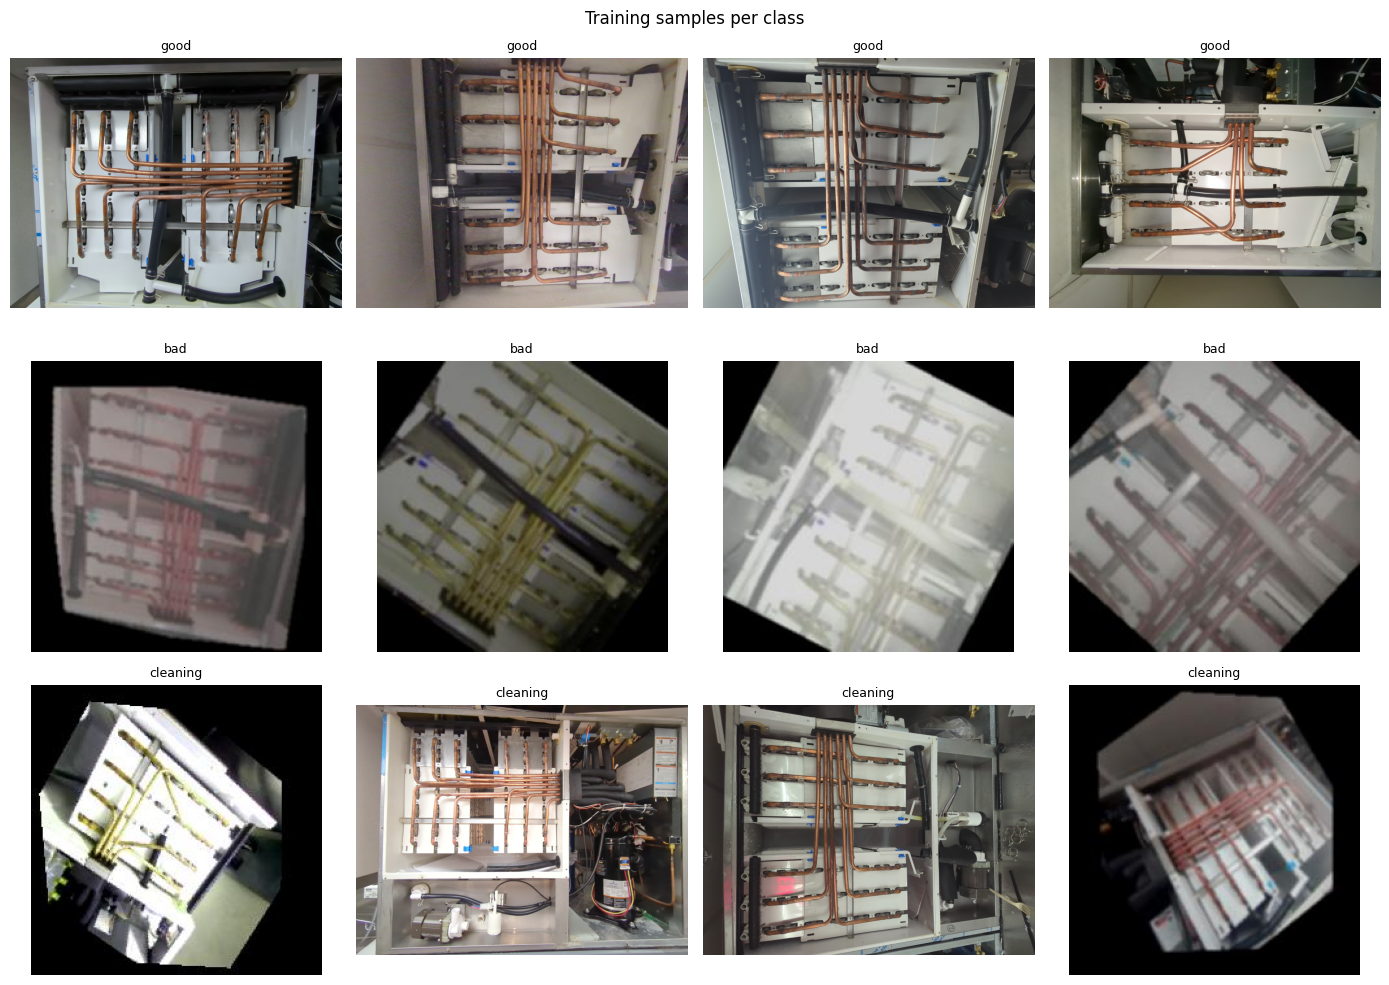

In [4]:
# Cell 4 — Augment small classes
aug_tf = T.Compose([
    T.RandomResizedCrop(224, scale=(0.5, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.1),
    T.RandomRotation(45),
    T.RandomPerspective(distortion_scale=0.3, p=0.5),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
])

def augment_to_target(paths, dest_dir: Path, target_count: int, label: str):
    """Augment photos until we reach target_count total."""
    dest_dir.mkdir(exist_ok=True)
    result = list(paths)  # start with originals

    # Copy originals first
    for p in paths:
        shutil.copy(p, dest_dir / p.name)

    needed = target_count - len(paths)
    if needed <= 0:
        print(f'  {label}: {len(paths)} photos — no augmentation needed')
        return result

    aug_per_photo = max(1, needed // max(1, len(paths))) + 1
    aug_paths = []
    for orig in paths:
        img = Image.open(orig).convert('RGB')
        for j in range(aug_per_photo):
            out_path = dest_dir / f'{orig.stem}_aug{j:03d}{orig.suffix}'
            aug_tf(img).save(out_path)
            aug_paths.append(out_path)
            if len(aug_paths) >= needed:
                break
        if len(aug_paths) >= needed:
            break

    result.extend(aug_paths)
    print(f'  {label}: {len(paths)} originals + {len(aug_paths)} augmented = {len(result)} total')
    return result

# Balance to the size of the largest class
target = max(len(good_paths), len(bad_paths), len(cleaning_paths))
print(f'Target count per class: {target}')
print()

aug_good_dir     = Path('aug_good')
aug_bad_dir      = Path('aug_bad')
aug_cleaning_dir = Path('aug_cleaning')

aug_good_paths     = augment_to_target(good_paths,     aug_good_dir,     target, 'good')
aug_bad_paths      = augment_to_target(bad_paths,      aug_bad_dir,      target, 'bad')
aug_cleaning_paths = augment_to_target(cleaning_paths, aug_cleaning_dir, target, 'cleaning')

# Preview
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row_i, (lbl, paths) in enumerate([('good', aug_good_paths), ('bad', aug_bad_paths), ('cleaning', aug_cleaning_paths)]):
    sample = random.sample(paths, min(4, len(paths)))
    for col_i, p in enumerate(sample):
        axes[row_i][col_i].imshow(Image.open(p))
        axes[row_i][col_i].set_title(f'{lbl}', fontsize=9)
        axes[row_i][col_i].axis('off')
plt.suptitle('Training samples per class')
plt.tight_layout()
plt.show()

---
# PART 3 — Stage 1: Detection Model
**"Is this a cube separator photo?"**

Binary EfficientNetB0:
- Positive: good + bad + cleaning photos
- Negative: not_cube_separator photos

Saves: `cube_separator_detector.pt`

In [5]:
# Cell 5 — Build detection dataset
DETECT_ROOT = Path('detect_split')
for split in ('train', 'val'):
    for cls in ('cube_separator', 'not_cube_separator'):
        (DETECT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

random.seed(42)

# Positive: all quality classes are "cube separator" for Stage 1
pos_paths = good_paths + bad_paths + cleaning_paths
random.shuffle(pos_paths)
split_pos = max(1, int(len(pos_paths) * 0.85))
for p in pos_paths[:split_pos]:
    shutil.copy(p, DETECT_ROOT / 'train' / 'cube_separator' / p.name)
for p in pos_paths[split_pos:]:
    shutil.copy(p, DETECT_ROOT / 'val' / 'cube_separator' / p.name)

# Negative
neg_paths = not_cs_paths[:]
random.shuffle(neg_paths)
split_neg = max(1, int(len(neg_paths) * 0.85))
for p in neg_paths[:split_neg]:
    shutil.copy(p, DETECT_ROOT / 'train' / 'not_cube_separator' / p.name)
for p in neg_paths[split_neg:]:
    shutil.copy(p, DETECT_ROOT / 'val' / 'not_cube_separator' / p.name)

for split in ('train', 'val'):
    counts = {c: len(list((DETECT_ROOT/split/c).iterdir())) for c in ('cube_separator','not_cube_separator')}
    print(f'{split}: {counts}')

train: {'cube_separator': 461, 'not_cube_separator': 427}
val: {'cube_separator': 82, 'not_cube_separator': 76}


In [6]:
# Cell 6 — Detection DataLoaders
BATCH = 16

det_train_tf = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

det_train_ds = ImageFolder(str(DETECT_ROOT / 'train'), transform=det_train_tf)
det_val_ds   = ImageFolder(str(DETECT_ROOT / 'val'),   transform=INFERENCE_TF)

counts_det = Counter(det_train_ds.targets)
sample_weights_det = [1.0 / counts_det[t] for t in det_train_ds.targets]
sampler_det = WeightedRandomSampler(sample_weights_det, num_samples=len(sample_weights_det), replacement=True)

det_train_loader = DataLoader(det_train_ds, batch_size=BATCH, sampler=sampler_det, num_workers=2)
det_val_loader   = DataLoader(det_val_ds,   batch_size=BATCH, shuffle=False,       num_workers=2)

print('class_to_idx:', det_train_ds.class_to_idx)
CS_IDX = det_train_ds.class_to_idx['cube_separator']
print(f'cube_separator class index: {CS_IDX}')

class_to_idx: {'cube_separator': 0, 'not_cube_separator': 1}
cube_separator class index: 0


In [8]:
import numpy as np # Importing numpy is already done in cell-2. This line is redundant here.
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # Disable the decompression bomb limit

# Cell 7 — Train detection model
def make_efficientnet(num_classes: int):
    net = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in net.parameters():
        param.requires_grad = False
    in_features = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, num_classes))
    return net.to(DEVICE)

def train_model(model, train_loader, val_loader, epochs, lr, unfreeze_blocks=None):
    if unfreeze_blocks:
        for name, param in model.named_parameters():
            if any(b in name for b in unfreeze_blocks) or 'classifier' in name:
                param.requires_grad = True
    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(params, lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_acc, best_state = 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        tr_correct, tr_total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            tr_correct += (model(imgs).argmax(1) == labels).sum().item()
            tr_total += len(imgs)
        model.eval()
        vl_correct, vl_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                vl_correct += (model(imgs).argmax(1) == labels).sum().item()
                vl_total += len(imgs)
        vl_acc = vl_correct / max(1, vl_total)
        scheduler.step()
        flag = ''
        if vl_acc > best_acc:
            best_acc = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            flag = '  ← saved'
        print(f'Ep {epoch:2d} | train={tr_correct/max(1,tr_total):.3f} | val={vl_acc:.3f}{flag}')
    model.load_state_dict(best_state)
    return best_acc

print('Building detection model (binary)...')
detector = make_efficientnet(num_classes=2)

print('Phase 1 — head only (12 epochs)')
acc1 = train_model(detector, det_train_loader, det_val_loader, epochs=12, lr=1e-3)

print(f'\nPhase 2 — fine-tune last blocks (12 epochs)')
acc2 = train_model(detector, det_train_loader, det_val_loader, epochs=12, lr=1e-4,
                   unfreeze_blocks=['features.7', 'features.8'])

print(f'\nBest detection val acc: {max(acc1, acc2):.3f}')

Building detection model (binary)...
Phase 1 — head only (12 epochs)
Ep  1 | train=0.887 | val=0.962  ← saved
Ep  2 | train=0.945 | val=0.968  ← saved
Ep  3 | train=0.948 | val=0.987  ← saved
Ep  4 | train=0.955 | val=0.987
Ep  5 | train=0.959 | val=0.987
Ep  6 | train=0.961 | val=0.981
Ep  7 | train=0.959 | val=0.994  ← saved
Ep  8 | train=0.965 | val=0.994
Ep  9 | train=0.958 | val=0.987
Ep 10 | train=0.963 | val=0.981
Ep 11 | train=0.943 | val=0.987
Ep 12 | train=0.965 | val=0.987

Phase 2 — fine-tune last blocks (12 epochs)
Ep  1 | train=0.976 | val=0.987  ← saved
Ep  2 | train=0.972 | val=0.987
Ep  3 | train=0.986 | val=0.987
Ep  4 | train=0.983 | val=0.981
Ep  5 | train=0.982 | val=0.987
Ep  6 | train=0.986 | val=0.987
Ep  7 | train=0.982 | val=0.994  ← saved
Ep  8 | train=0.988 | val=0.987
Ep  9 | train=0.986 | val=0.994
Ep 10 | train=0.985 | val=0.994
Ep 11 | train=0.983 | val=0.994
Ep 12 | train=0.975 | val=0.994

Best detection val acc: 0.994


                    precision    recall  f1-score   support

    cube_separator       1.00      0.99      0.99        82
not_cube_separator       0.99      1.00      0.99        76

          accuracy                           0.99       158
         macro avg       0.99      0.99      0.99       158
      weighted avg       0.99      0.99      0.99       158



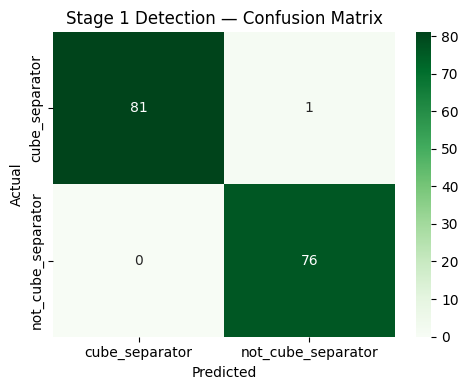

Saved: cube_separator_detector.pt


In [9]:
# Cell 8 — Evaluate and save detection model
detector.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in det_val_loader:
        preds = detector(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=det_val_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=det_val_ds.classes, yticklabels=det_val_ds.classes, cmap='Greens')
plt.title('Stage 1 Detection — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('detector_confusion.png', dpi=150)
plt.show()

det_bundle = {
    'model_state_dict': detector.state_dict(),
    'class_to_idx': det_train_ds.class_to_idx,
    'idx_to_class': {v: k for k, v in det_train_ds.class_to_idx.items()},
    'cs_class_idx': CS_IDX,
    'architecture': 'efficientnet_b0',
    'val_acc': round(max(acc1, acc2), 4),
    'version': 2,
}
torch.save(det_bundle, 'cube_separator_detector.pt')
print('Saved: cube_separator_detector.pt')

---
# PART 4 — Stage 2: Quality Model (3-class)
**"Is this good, bad, or cleaning?"**

Supervised EfficientNetB0 trained on all 3 quality classes.
Replaces V1's DINOv2 + Isolation Forest — no anomaly scores, just a class + confidence.

Saves: `cube_separator_quality.pt`

In [10]:
# Cell 9 — Build quality dataset (good / bad / cleaning)
QUALITY_ROOT = Path('quality_split')
for split in ('train', 'val'):
    for cls in ('good', 'bad', 'cleaning'):
        (QUALITY_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

random.seed(42)

def split_and_copy(paths, class_name, split_ratio=0.85):
    shuffled = list(paths)
    random.shuffle(shuffled)
    n_train = max(1, int(len(shuffled) * split_ratio))
    for p in shuffled[:n_train]:
        shutil.copy(p, QUALITY_ROOT / 'train' / class_name / p.name)
    for p in shuffled[n_train:]:
        shutil.copy(p, QUALITY_ROOT / 'val' / class_name / p.name)
    return n_train, len(shuffled) - n_train

# Use augmented paths so classes are balanced
tr_g, vl_g = split_and_copy(aug_good_paths,     'good')
tr_b, vl_b = split_and_copy(aug_bad_paths,      'bad')
tr_c, vl_c = split_and_copy(aug_cleaning_paths, 'cleaning')

print('Quality dataset split:')
print(f'  good     train={tr_g}  val={vl_g}')
print(f'  bad      train={tr_b}  val={vl_b}')
print(f'  cleaning train={tr_c}  val={vl_c}')

Quality dataset split:
  good     train=324  val=58
  bad      train=324  val=58
  cleaning train=324  val=58


In [11]:
# Cell 10 — Quality DataLoaders
qual_train_tf = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

qual_train_ds = ImageFolder(str(QUALITY_ROOT / 'train'), transform=qual_train_tf)
qual_val_ds   = ImageFolder(str(QUALITY_ROOT / 'val'),   transform=INFERENCE_TF)

# Weighted sampler to handle any remaining class imbalance
counts_qual = Counter(qual_train_ds.targets)
sample_weights_qual = [1.0 / counts_qual[t] for t in qual_train_ds.targets]
sampler_qual = WeightedRandomSampler(sample_weights_qual, num_samples=len(sample_weights_qual), replacement=True)

qual_train_loader = DataLoader(qual_train_ds, batch_size=BATCH, sampler=sampler_qual, num_workers=2)
qual_val_loader   = DataLoader(qual_val_ds,   batch_size=BATCH, shuffle=False,        num_workers=2)

print('class_to_idx:', qual_train_ds.class_to_idx)
# Store for report script
QUAL_IDX_TO_CLASS = {v: k for k, v in qual_train_ds.class_to_idx.items()}

class_to_idx: {'bad': 0, 'cleaning': 1, 'good': 2}


In [12]:
# Cell 11 — Train quality model
print('Building quality model (3-class: good / bad / cleaning)...')
quality_net = make_efficientnet(num_classes=3)

print('Phase 1 — head only (15 epochs)')
qacc1 = train_model(quality_net, qual_train_loader, qual_val_loader, epochs=15, lr=1e-3)

print(f'\nPhase 2 — fine-tune last blocks (15 epochs)')
qacc2 = train_model(quality_net, qual_train_loader, qual_val_loader, epochs=15, lr=5e-5,
                    unfreeze_blocks=['features.6', 'features.7', 'features.8'])

print(f'\nBest quality val acc: {max(qacc1, qacc2):.3f}')

Building quality model (3-class: good / bad / cleaning)...
Phase 1 — head only (15 epochs)
Ep  1 | train=0.635 | val=0.747  ← saved
Ep  2 | train=0.691 | val=0.782  ← saved
Ep  3 | train=0.748 | val=0.782
Ep  4 | train=0.744 | val=0.799  ← saved
Ep  5 | train=0.773 | val=0.793
Ep  6 | train=0.750 | val=0.810  ← saved
Ep  7 | train=0.756 | val=0.839  ← saved
Ep  8 | train=0.785 | val=0.822
Ep  9 | train=0.784 | val=0.828
Ep 10 | train=0.808 | val=0.833
Ep 11 | train=0.795 | val=0.828
Ep 12 | train=0.807 | val=0.822
Ep 13 | train=0.778 | val=0.833
Ep 14 | train=0.792 | val=0.828
Ep 15 | train=0.789 | val=0.839

Phase 2 — fine-tune last blocks (15 epochs)
Ep  1 | train=0.811 | val=0.839  ← saved
Ep  2 | train=0.851 | val=0.902  ← saved
Ep  3 | train=0.876 | val=0.908  ← saved
Ep  4 | train=0.889 | val=0.914  ← saved
Ep  5 | train=0.905 | val=0.937  ← saved
Ep  6 | train=0.914 | val=0.937
Ep  7 | train=0.907 | val=0.948  ← saved
Ep  8 | train=0.933 | val=0.954  ← saved
Ep  9 | train=0.938 

              precision    recall  f1-score   support

         bad       0.98      1.00      0.99        58
    cleaning       1.00      0.91      0.95        58
        good       0.94      1.00      0.97        58

    accuracy                           0.97       174
   macro avg       0.97      0.97      0.97       174
weighted avg       0.97      0.97      0.97       174



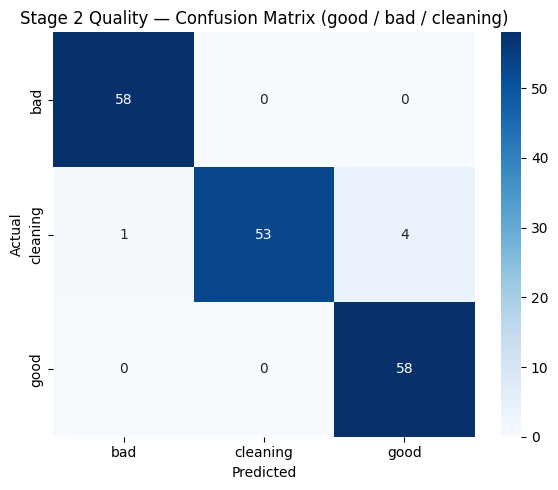


Pay attention to bad recall (row=bad).  If bad photos are often predicted as
good or cleaning, add more labeled bad photos and retrain.


In [13]:
# Cell 12 — Evaluate quality model
quality_net.eval()
all_preds_q, all_labels_q = [], []
with torch.no_grad():
    for imgs, labels in qual_val_loader:
        preds = quality_net(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds_q.extend(preds)
        all_labels_q.extend(labels.numpy())

class_names = qual_val_ds.classes   # alphabetical: ['bad', 'cleaning', 'good']
print(classification_report(all_labels_q, all_preds_q, target_names=class_names))

cm_q = confusion_matrix(all_labels_q, all_preds_q)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_q, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Stage 2 Quality — Confusion Matrix (good / bad / cleaning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('quality_confusion.png', dpi=150)
plt.show()

print()
print('Pay attention to bad recall (row=bad).  If bad photos are often predicted as')
print('good or cleaning, add more labeled bad photos and retrain.')

In [14]:
# Cell 13 — Save quality model
qual_bundle = {
    'model_state_dict': quality_net.state_dict(),
    'class_to_idx': qual_train_ds.class_to_idx,
    'idx_to_class': QUAL_IDX_TO_CLASS,
    'architecture': 'efficientnet_b0',
    'num_classes': 3,
    'classes': class_names,
    'val_acc': round(max(qacc1, qacc2), 4),
    'version': 2,
    'training_counts': {
        'good':     len(aug_good_paths),
        'bad':      len(aug_bad_paths),
        'cleaning': len(aug_cleaning_paths),
    },
}
torch.save(qual_bundle, 'cube_separator_quality.pt')
print('Saved: cube_separator_quality.pt')
print(f'  val_acc : {qual_bundle["val_acc"]}')
print(f'  classes : {class_names}')
print(f'  counts  : {qual_bundle["training_counts"]}')

Saved: cube_separator_quality.pt
  val_acc : 0.9713
  classes : ['bad', 'cleaning', 'good']
  counts  : {'good': 382, 'bad': 382, 'cleaning': 382}


---
# PART 5 — Download Models

In [15]:
# Cell 14 — Download all output files
from google.colab import files

for fname in ['cube_separator_detector.pt', 'cube_separator_quality.pt',
              'detector_confusion.png', 'quality_confusion.png']:
    print(f'Downloading {fname} ...')
    files.download(fname)

print('\nDrop cube_separator_detector.pt and cube_separator_quality.pt')
print('into your cube_separator/ folder, then run:')
print('  python3 run_cube_separator_report.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Drop cube_separator_detector.pt and cube_separator_quality.pt
into your cube_separator/ folder, then run:
  python3 run_cube_separator_report.py
